# FRAUD DETECTION PIPELINE
## CLASSIFICATION MODEL

In [2]:
#import necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

ABOUT DATA 

Credit card transaction 

In [3]:
#Load Data

df = pd.read_csv("creditcard.csv")

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape

(284807, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.nunique()

Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663
V27       275663
V28       275663
Amount     32767
Class          2
dtype: int64

Class is a categorical column. 

In [8]:
df.duplicated().sum()

1081

In [9]:
df.drop_duplicates(inplace = True)
df.shape

(283726, 31)

In [10]:
df.drop(columns="Time", inplace=True)

## VISUALIZATIONS

Text(0.5, 1.0, 'Distribution of Amount')

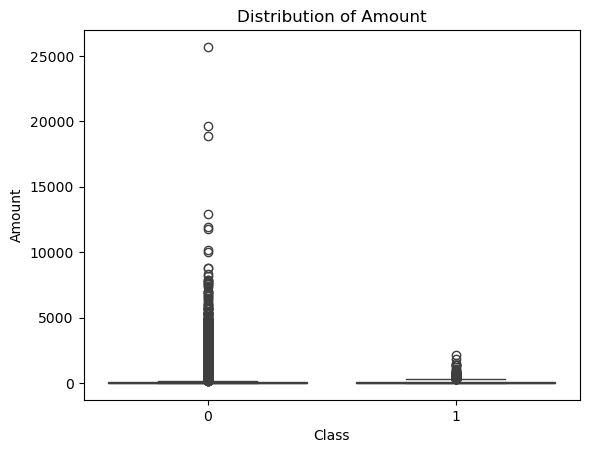

In [11]:
#Distribution of Class by Amount

sns.boxplot(x="Class", y="Amount", data=df)
#axes label
plt.xlabel("Class")
plt.ylabel("Amount")
plt.title("Distribution of Amount")

<Axes: title={'center': 'Class Balance'}, xlabel='Class', ylabel='Frequency'>

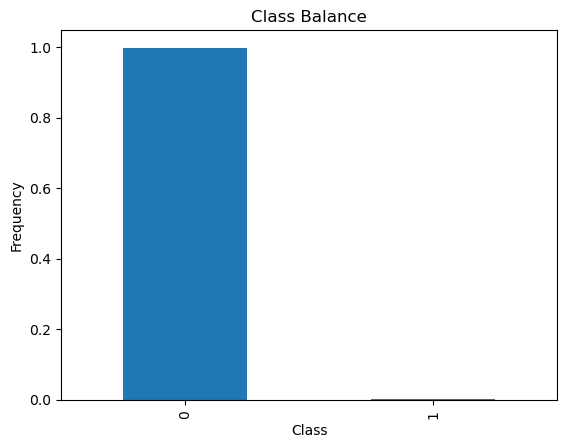

In [12]:
#Class Balance 
df["Class"].value_counts(normalize=True).plot(kind="bar", xlabel="Class", ylabel="Frequency", title="Class Balance")

This is a very Unbalance Class

## Split

In [13]:
target = "Class"
X = df.drop(columns = target)
y = df[target]


In [14]:
y.value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

### Train-Test Split

In [15]:
X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, random_state= 42)

In [16]:
# Check for correlation of target and features

numeric_cols = X.select_dtypes(include=np.number).columns

corr_with_target = X.apply(lambda col: col.corr(y))

print("\nCorrelation with target:")
print(corr_with_target)


Correlation with target:
V1       -0.094486
V2        0.084624
V3       -0.182322
V4        0.129326
V5       -0.087812
V6       -0.043915
V7       -0.172347
V8        0.033068
V9       -0.094021
V10      -0.206971
V11       0.149067
V12      -0.250711
V13      -0.003897
V14      -0.293375
V15      -0.003300
V16      -0.187186
V17      -0.313498
V18      -0.105340
V19       0.033631
V20       0.021486
V21       0.026357
V22       0.004887
V23      -0.006333
V24      -0.007210
V25       0.003202
V26       0.004265
V27       0.021892
V28       0.009682
Amount    0.005777
dtype: float64


## Preprocessing

In [17]:
#numeric_features = X_train.select_dtypes(include=['float64']).columns.tolist()

from sklearn.preprocessing import StandardScaler

# Build Pipeline

In [18]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('resample', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

### Build Model

In [19]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('resample', SMOTE(random_state=42)),
                ('classifier', RandomForestClassifier(random_state=42))])

### Evaluate the Model

In [20]:
y_pred = pipeline.predict(X_test)


#Print the classification report¶

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    226597
           1       0.79      0.74      0.76       383

    accuracy                           1.00    226980
   macro avg       0.90      0.87      0.88    226980
weighted avg       1.00      1.00      1.00    226980



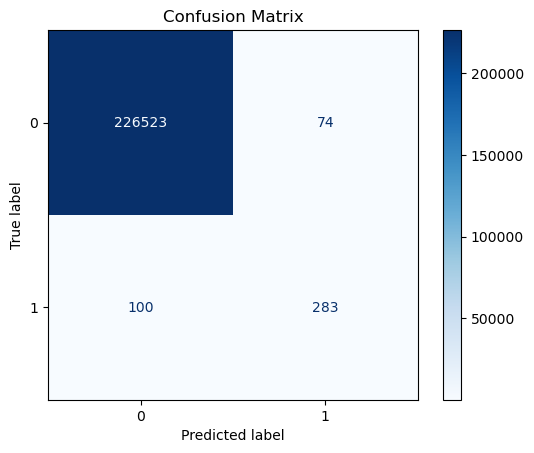

In [21]:
#Plot the confusion matrix

conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

True Negatives of 22653
False Positives of 74 
False Negatives of 100

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
pipeline2 = Pipeline([
    ('scaler', StandardScaler()),
    ('resample', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42))
])
pipeline2.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('resample', SMOTE(random_state=42)),
                ('classifier', LogisticRegression(random_state=42))])

In [24]:
y_pred2 = pipeline2.predict(X_test)


#Print the classification report¶

print("\nClassification Report:")
print(classification_report(y_test, y_pred2))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    226597
           1       0.04      0.92      0.08       383

    accuracy                           0.96    226980
   macro avg       0.52      0.94      0.53    226980
weighted avg       1.00      0.96      0.98    226980



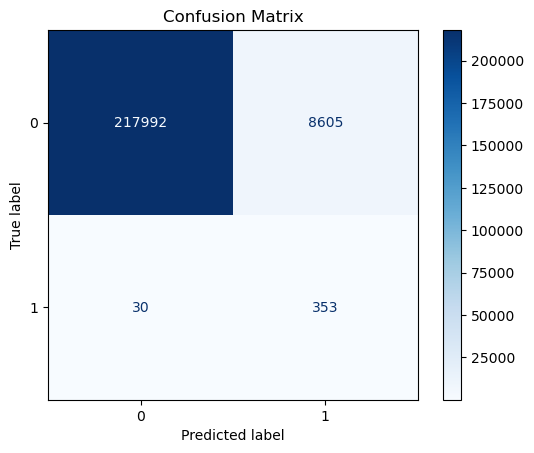

In [25]:
#Plot the confusion matrix

conf_matrix = confusion_matrix(y_test, y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()